# Local Smart Meter Analytics with DuckDB

This notebook shows the local laptop version of the smart meter analytics platform.

Audience:
- Beginners who want to understand the flow.
- Engineers who want reusable local SQL and dashboard data.

By the end, you can query the smart meter dataset locally with DuckDB, inspect fleet health metrics, and connect the same DuckDB database to Apache Superset.

## 1. Local Architecture

```text
CSV / Parquet files
  -> DuckDB database
  -> SQL views
  -> Jupyter exploration
  -> Apache Superset local dashboard
```

DuckDB is an embedded analytical database. It does not need a separate database server. It can query CSV and Parquet files directly.

In [1]:
from pathlib import Path

import duckdb
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path('..').resolve()
DB_PATH = ROOT / 'duckdb' / 'smart_meter.duckdb'
DATA_DIR = ROOT / 'data'

print(DB_PATH)
print(DATA_DIR)

Matplotlib is building the font cache; this may take a moment.


/Users/shivamkumar/Desktop/temp/smart-meter/local/duckdb/smart_meter.duckdb
/Users/shivamkumar/Desktop/temp/smart-meter/local/data


## 2. Connect to DuckDB

The setup script already created `local/duckdb/smart_meter.duckdb`. We connect to it in read-only mode so notebook exploration cannot accidentally change the database.

In [2]:
con = duckdb.connect(str(DB_PATH), read_only=True)
con.execute("SHOW TABLES").fetchdf()

,name
0,smart_meter_fleet_health
1,vw_battery_health
2,vw_communication_health
3,vw_daily_consumption
4,vw_electrical_health
5,vw_firmware_distribution
6,vw_fleet_summary
7,vw_geographic_health
8,vw_health_by_status
9,vw_monthly_consumption


## 3. Fleet Summary

This is the same high-level executive summary used by the cloud dashboard.

In [3]:
fleet_summary = con.execute("SELECT * FROM vw_fleet_summary").fetchdf()
fleet_summary

,total_meters,healthy,warning,critical,average_voltage,average_rssi,average_battery_pct,average_consumption_kwh
0,50000,40134.0,9848.0,18.0,223.17,-71.96,76.97,0.889


## 4. Health Status Split

This answers: how many readings are healthy, warning, or critical?

In [4]:
health = con.execute("""
SELECT health_status, readings, meters
FROM vw_health_by_status
ORDER BY readings DESC
""").fetchdf()
health

,health_status,readings,meters
0,Healthy,40134,40134
1,Warning,9848,9848
2,Critical,18,18


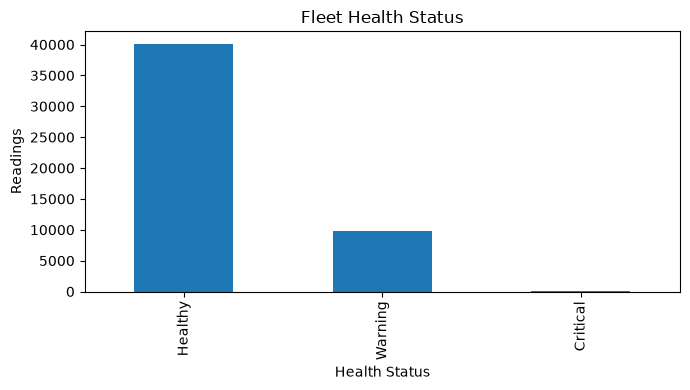

In [5]:
ax = health.plot(kind='bar', x='health_status', y='readings', legend=False, figsize=(7, 4), title='Fleet Health Status')
ax.set_xlabel('Health Status')
ax.set_ylabel('Readings')
plt.tight_layout()

## 5. Communication Health

RSSI is radio signal strength. Lower values are weaker. This query finds the weakest states by RSSI.

In [6]:
comm = con.execute("""
SELECT state, MIN(worst_rssi) AS worst_rssi, ROUND(AVG(average_rssi), 2) AS average_rssi
FROM vw_communication_health
GROUP BY state
ORDER BY worst_rssi ASC
""").fetchdf()
comm

,state,worst_rssi,average_rssi
0,Maharashtra,-115.0,-72.13
1,Karnataka,-115.0,-71.93
2,Andhra Pradesh,-115.0,-71.92
3,Telangana,-115.0,-71.99
4,Tamil Nadu,-112.9,-71.85


## 6. Electrical Health

Voltage and power factor issues can affect billing, asset health, and customer experience.

In [7]:
electrical = con.execute("""
SELECT state, SUM(voltage_violations) AS voltage_violations,
       SUM(low_power_factor) AS low_power_factor,
       ROUND(AVG(average_voltage), 2) AS average_voltage
FROM vw_electrical_health
GROUP BY state
ORDER BY voltage_violations DESC
""").fetchdf()
electrical

,state,voltage_violations,low_power_factor,average_voltage
0,Andhra Pradesh,863.0,0.0,223.29
1,Maharashtra,855.0,0.0,223.46
2,Telangana,846.0,0.0,222.82
3,Tamil Nadu,842.0,0.0,223.15
4,Karnataka,815.0,0.0,223.14


## 7. Battery Health

Battery health helps operations teams plan replacement or field maintenance.

In [8]:
battery = con.execute("""
SELECT battery_status, SUM(devices) AS devices, ROUND(AVG(average_battery_pct), 2) AS average_battery_pct
FROM vw_battery_health
GROUP BY battery_status
ORDER BY devices DESC
""").fetchdf()
battery

,battery_status,devices,average_battery_pct
0,Good,48458.0,78.23
1,Medium,1516.0,37.73
2,Low,26.0,14.29


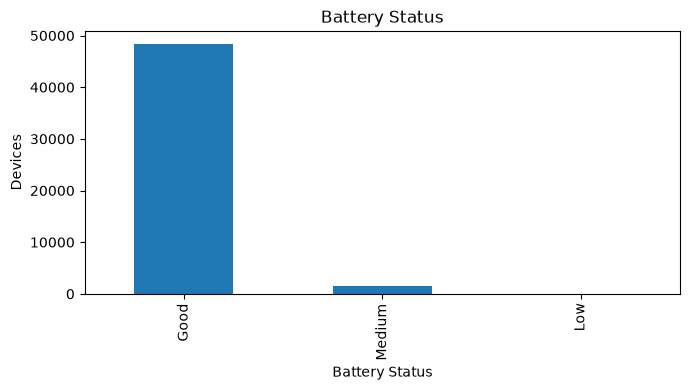

In [9]:
ax = battery.plot(kind='bar', x='battery_status', y='devices', legend=False, figsize=(7, 4), title='Battery Status')
ax.set_xlabel('Battery Status')
ax.set_ylabel('Devices')
plt.tight_layout()

## 8. Consumption Trend

This query creates a daily consumption trend across the whole fleet.

In [10]:
daily = con.execute("""
SELECT event_date, SUM(total_consumption_kwh) AS total_consumption_kwh
FROM vw_daily_consumption
GROUP BY event_date
ORDER BY event_date
""").fetchdf()
daily.head()

,event_date,total_consumption_kwh
0,2024-01-01,132.555
1,2024-01-02,110.748
2,2024-01-03,112.655
3,2024-01-04,132.045
4,2024-01-05,111.390


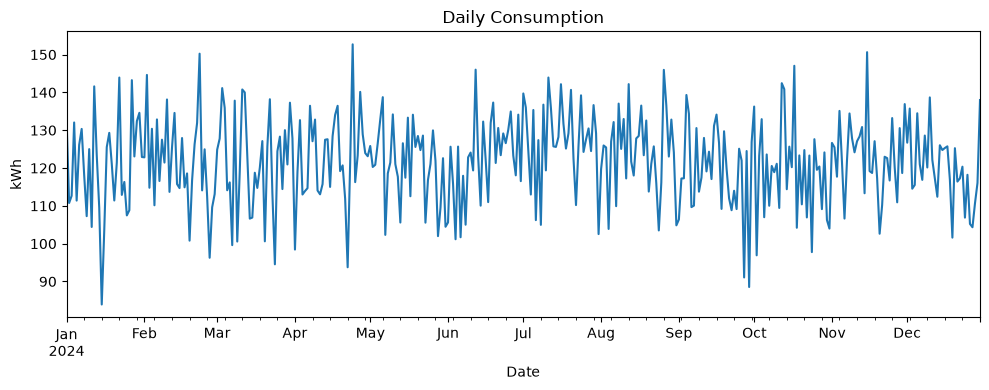

In [11]:
ax = daily.plot(kind='line', x='event_date', y='total_consumption_kwh', legend=False, figsize=(10, 4), title='Daily Consumption')
ax.set_xlabel('Date')
ax.set_ylabel('kWh')
plt.tight_layout()

## 9. Firmware Distribution

This helps identify whether specific firmware versions correlate with more issues.

In [12]:
firmware = con.execute("""
SELECT firmware_version, SUM(meters) AS meters,
       SUM(communication_issues) AS communication_issues,
       SUM(signal_issues) AS signal_issues,
       SUM(voltage_issues) AS voltage_issues
FROM vw_firmware_distribution
GROUP BY firmware_version
ORDER BY meters DESC
""").fetchdf()
firmware

,firmware_version,meters,communication_issues,signal_issues,voltage_issues
0,FW-2.1.3,13916.0,817.0,968.0,1164.0
1,FW-2.2.0,13901.0,824.0,891.0,1129.0
2,FW-2.3.1,9207.0,567.0,585.0,809.0
3,FW-2.1.0,9001.0,585.0,574.0,802.0
4,FW-1.9.8,3975.0,246.0,266.0,317.0


## 10. Top Consumers

This query is useful for inspection and for validating consumption outliers.

In [13]:
top_consumers = con.execute("""
SELECT *
FROM vw_top_consumers
ORDER BY total_consumption_kwh DESC
LIMIT 10
""").fetchdf()
top_consumers

,meter_id,state,district,discom,feeder_id,total_consumption_kwh,average_voltage,average_current,last_seen_at
0,SM00021944,Maharashtra,Pune,Ikeja,IKJ-SS-003-FD-035,2.781,213.0,14.20,2024-01-13 19:00:00
1,SM00030413,Maharashtra,Thane,Ikeja,IKJ-SS-002-FD-005,2.748,234.6,13.78,2024-01-13 19:00:00
2,SM00012194,Andhra Pradesh,Krishna,Kano,KNO-SS-002-FD-042,2.725,229.9,12.88,2024-01-04 19:00:00
3,SM00023364,Andhra Pradesh,Bapatla,Jos,JOS-SS-002-FD-024,2.689,222.2,13.75,2024-02-18 19:00:00
4,SM00034824,Karnataka,Dharwad,Kano,KNO-SS-002-FD-058,2.660,212.9,13.88,2024-11-15 20:00:00
5,SM00023507,Karnataka,Belagavi,Abuja,ABJ-SS-002-FD-007,2.655,213.9,14.11,2024-05-10 19:00:00
6,SM00015507,Tamil Nadu,Madurai,Kaduna,KAD-SS-002-FD-052,2.624,228.6,12.48,2024-06-17 18:00:00
7,SM00004460,Andhra Pradesh,Guntur,Jos,JOS-SS-002-FD-051,2.620,215.4,13.82,2024-09-18 19:00:00
8,SM00033436,Andhra Pradesh,Guntur,Eko,EKO-SS-001-FD-044,2.611,214.0,12.84,2024-10-23 19:00:00
9,SM00038065,Maharashtra,Aurangabad,Port Harcourt,PHC-SS-002-FD-036,2.603,244.1,11.85,2024-10-16 19:00:00


## 11. Superset Connection

After running `./scripts/init_superset.sh` and `./scripts/run_superset.sh`, open Superset at:

```text
http://localhost:8088
```

Use this DuckDB SQLAlchemy URI:

```python
"duckdb:///" + str(DB_PATH)
```

Then create charts from these views:

- `vw_fleet_summary`
- `vw_health_by_status`
- `vw_daily_consumption`
- `vw_geographic_health`
- `vw_firmware_distribution`
- `vw_top_consumers`

In [14]:
print('Superset DuckDB URI:')
print('duckdb:///' + str(DB_PATH))

Superset DuckDB URI:
duckdb:////Users/shivamkumar/Desktop/temp/smart-meter/local/duckdb/smart_meter.duckdb


## 12. Exercise

Try writing a query that finds the top 5 districts by warning readings.

Hint: use `smart_meter_fleet_health`, filter `health_status = 'Warning'`, group by district, and order descending.

In [15]:
# Exercise answer scaffold
warning_districts = con.execute("""
SELECT district, COUNT(*) AS warning_readings
FROM smart_meter_fleet_health
WHERE health_status = 'Warning'
GROUP BY district
ORDER BY warning_readings DESC
LIMIT 5
""").fetchdf()
warning_districts

,district,warning_readings
0,NTR,428
1,Krishna,427
2,Khammam,419
3,Nagpur,416
4,Thane,412


## 13. Common Pitfalls

- If `smart_meter.duckdb` is missing, run `python scripts/build_duckdb.py` from `local/`.
- If Superset cannot connect, use the absolute `duckdb:///.../smart_meter.duckdb` URI.
- If a notebook query fails, restart the kernel and run from the top.

## 14. Next Extensions

- Add anomaly detection with rolling averages.
- Add synthetic alert severity labels.
- Create Superset charts for all DuckDB views.
- Compare local DuckDB results against Athena results.